Code: https://github.com/zhurleonid/corporate-risk-management
(`homework_1/hw1_code.ipynb`)

The write-up is below. The code is appended at the end.

# Setup

Daily SPY closes from Yahoo Finance. Log returns are
$x_i = \log(s_i / s_{i-1})$, and I take $\Delta = 1/252$ throughout, so
annualized volatility is $\hat\sigma_A = \sqrt{\hat\sigma^2/\Delta}$.

The download starts in June 2020, not August 2021. The extra year is there so
the 100-day window is already full on the first day I have to plot. That leaves
1552 closes and 1551 returns.

# MA and EWMA estimates

## Pseudocode

```
read closes s_0 ... s_N, set n = 100, lambda = 0.94, Delta = 1/252
x_i = log(s_i / s_{i-1})                     for i = 1 ... N

MA(n):
for i = n+1 ... N:
    window = x_{i-n} ... x_{i-1}             the n returns ending the day before
    mu     = mean(window)
    var_i  = sum over window of (x - mu)^2 / (n - 1)

EWMA(lambda):
var = variance of x_1 ... x_n                (same (n-1) divisor)
for i = n+1 ... N:
    var   = lambda*var + (1 - lambda)*x_{i-1}^2
    var_i = var

annualize both:  sigma_i = sqrt(var_i / Delta)
plot MA and EWMA on the same axes, restricted to 08/01/2021 - 07/30/2026
```

Neither estimator looks ahead: day $i$ uses returns through $i-1$ only, so
$\sigma_{t+\Delta}$ is known at $t$.

The problem lets me seed EWMA with the sample variance of the past 100 days.
I seed at the start of the download, which gives the recursion 194 steps to
settle before the plot window opens. Under the alternative reading, where the
seed comes from the 100 days right before 08/01/2021, the first plotted value
moves by 0.0027, and nothing after day 51 moves by more than $10^{-4}$. Mean,
min and max come out the same to four decimals.

## Results

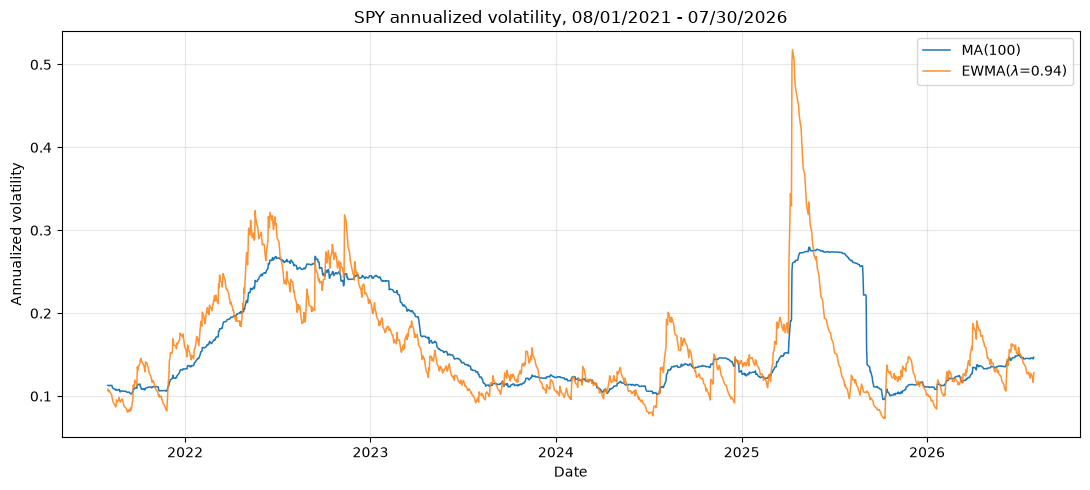

*Annualized volatility of SPY daily log returns, 08/01/2021-07/30/2026, estimated by MA(100) and EWMA(lambda = 0.94).*

$$\begin{array}{l r r}
\hline
 & \text{MA(100)} & \text{EWMA(0.94)} \\
\hline
\text{mean} & 0.1614 & 0.1583 \\
\text{std}  & 0.0576 & 0.0664 \\
\text{min}  & 0.0958 & 0.0730 \\
\text{max}  & 0.2794 & 0.5177 \\
\hline
\end{array}$$

Both series average about the same, 16.1% against 15.8%, and there the
similarity ends. EWMA is far more reactive. It peaks at 51.8% against the MA's
27.9%, and it comes back down almost as quickly as it went up.

The MA is smoother only in the sense that it moves less day to day. What it
actually does is hold every shock for exactly 100 days and then drop it. The
April 2025 spike shows this plainly: the MA climbs, sits near its peak for
months, then falls off a cliff the day those returns leave the window. The
plateaus and cliffs in the plot are all this same artifact.

# Fitting GARCH(1,1)

The model is

$$\sigma^2_{t+\Delta} = \alpha_0 + \alpha_1 X_t^2 + \beta_1 \sigma_t^2,
\qquad X_{t+\Delta} = \sigma_{t+\Delta} Z_{k+1}, \quad Z \sim N(0,1).$$

With Gaussian $Z$, maximizing the log-likelihood reduces to minimizing

$$\sum_i \left( \log \sigma_i^2 + \frac{x_i^2}{\sigma_i^2} \right),
\qquad
\sigma_i^2 = \alpha_0 + \alpha_1 x_{i-1}^2 + \beta_1 \sigma_{i-1}^2 .$$

## Pseudocode

```
x = the returns from 06/01/2025 to 05/31/2026        (250 of them)

function neg_loglik(a0, a1, b1):
    if a0 <= 0 or a1 < 0 or b1 < 0 or a1 + b1 >= 1:
        return a huge number                 keeps the search inside the region
    var   = variance(x)                      sigma_1^2
    total = 0
    for t = 1 ... 250:
        total = total + log(var) + x_t^2 / var
        var   = a0 + a1*x_t^2 + b1*var       variance for the NEXT day
    return total

(a0, a1, b1) = the (a0,a1,b1) minimizing neg_loglik, by Nelder-Mead
               from 3 starting guesses, keeping whichever lands lowest
V_L = a0 / (1 - a1 - b1)

in-sample fitted volatility, same recursion, parameters now fixed:
    var = variance(x)
    for t = 1 ... 250:
        record sqrt(var / Delta)
        var = a0 + a1*x_t^2 + b1*var
    keep the final var as sigma^2_N for reference
```

## Results

The fit window holds 250 trading days, 06/02/2025 through 05/29/2026. Forming
that first return needs the 05/30/2025 close, one price outside the stated
window. That is unavoidable when the window is given in prices and the model is
fitted on returns.

Minimizing the negative log-likelihood with Nelder-Mead:

$$\begin{array}{l r}
\hline
\alpha_0 & 6.7425 \times 10^{-6} \\
\alpha_1 & 0.0581 \\
\beta_1 & 0.8236 \\
\hline
\alpha_1 + \beta_1 & 0.8817 \\
V_L & 5.6987 \times 10^{-5} \\
\sqrt{V_L/\Delta} \;(\text{ann. vol}) & 11.98\% \\
-\ell(\hat\theta) & -2199.64 \\
\hline
\end{array}$$

With $\alpha_1 + \beta_1 = 0.8817 < 1$ the fit is stationary, so forecasts
pull back toward $V_L$. The stationarity constraint was not binding at the
optimum. Since $\beta_1$ dwarfs $\alpha_1$, a shock enters the variance
weakly on the day it lands and then decays.

How fast it decays is worth dwelling on. $(\alpha_1+\beta_1)^n$ halves in
$\log 0.5/\log 0.8817 = 5.5$ days and is 90% gone inside 18. Multi-year fits
of daily SPY typically land near 0.98, a half-life closer to 34 days. This
window, a calm year apart from March, mean-reverts unusually quickly. That is
exactly why the forecasts below flatten onto $V_L$ within about three weeks.

I ran the optimizer from three different starting guesses and they all converged
to the same parameters, so this appears to be the actual minimum rather than a
local one.

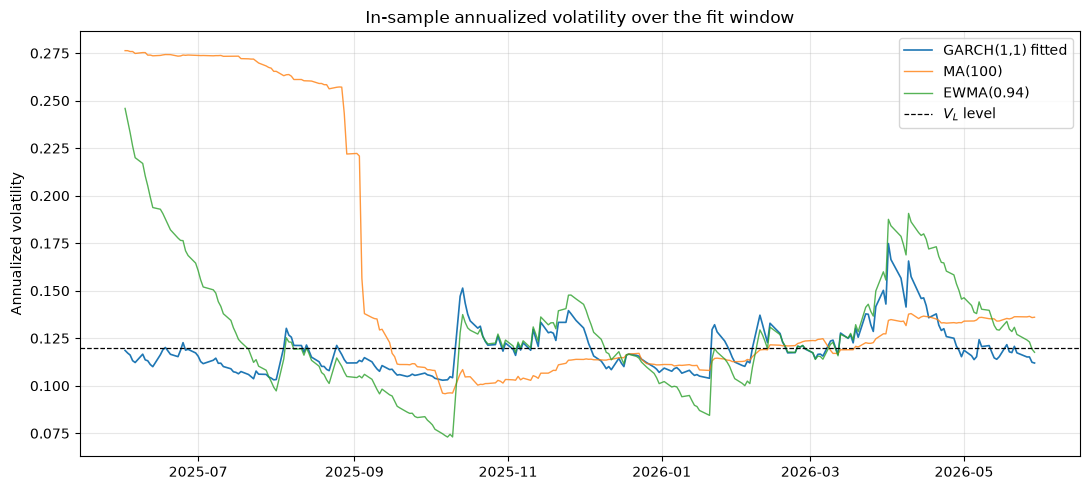

*In-sample annualized volatility over the fit window: GARCH(1,1) conditional volatility against MA(100), EWMA(0.94), and the long-run level.*

# Forecasting 06/01/2026 - 07/30/2026

The notes' pseudocode sets $\sigma_N^2$ to the sample variance of the fit
returns, 11.86% annualized. From there I roll the recursion forward, drawing a
fresh shock each day, and repeat $M = 100$ times over the $m = 42$ trading days
in the horizon.

Carrying the filtered $\sigma^2_N$ out of the fit would be cleaner in
principle, since it is the model's own state at the forecast origin, 11.01%
here. I follow the notes instead. Given how fast this fit mean-reverts, the two
seeds converge within days.

## Pseudocode

```
use the fitted a0, a1, b1 and V_L from part 2
var_start = variance(x)                      the notes' choice of sigma_N^2
x_last    = the last return of the fit window
m = 42 days from 06/01/2026 to 07/30/2026,  M = 100

simulated paths:
for j = 1 ... M:
    var    = var_start
    x_prev = x_last
    for d = 1 ... m:
        var          = a0 + a1*x_prev^2 + b1*var
        path[j][d]   = sqrt(var / Delta)
        draw Z from N(0,1)
        x_prev       = sqrt(var)*Z           the simulated next return

expected path:
    sigma^2_1 = a0 + a1*x_last^2 + b1*var_start
                this is the d = 1 value of the loop above, identical for every
                path, which is why day 1 has no spread
    for n = 1 ... m:
        E_n = V_L + (a1 + b1)^(n-1) * (sigma^2_1 - V_L)
        record sqrt(E_n / Delta)

take the 5%, 50% and 95% quantiles across the M paths for each day
plot the paths, their median, the expected path, and the MA and EWMA
estimates over the same 42 days
```

## Results

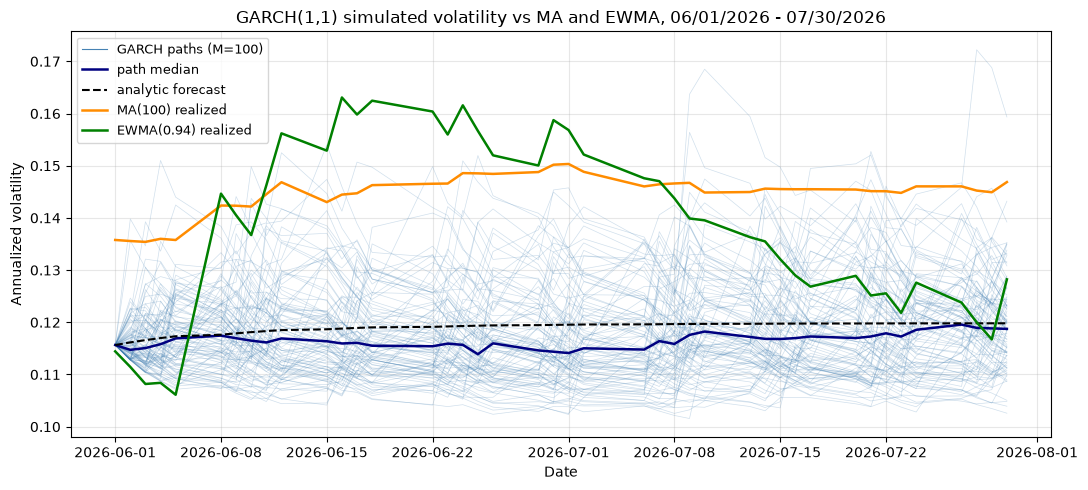

*100 simulated GARCH(1,1) annualized volatility paths over 06/01/2026-07/30/2026, with the path median and the analytic expected path, compared against the realized MA(100) and EWMA(0.94) estimates.*

$$\begin{array}{l r r r r r r}
\hline
\text{Date} & \text{GARCH med.} & 5\% & 95\% & \text{analytic} & \text{MA(100)} & \text{EWMA(0.94)} \\
\hline
\text{2026-06-01} & 0.1156 & 0.1156 & 0.1156 & 0.1156 & 0.1358 & 0.1144 \\
\text{2026-06-12} & 0.1169 & 0.1072 & 0.1367 & 0.1185 & 0.1468 & 0.1562 \\
\text{2026-06-29} & 0.1146 & 0.1051 & 0.1352 & 0.1195 & 0.1488 & 0.1500 \\
\text{2026-07-14} & 0.1168 & 0.1063 & 0.1399 & 0.1197 & 0.1456 & 0.1355 \\
\text{2026-07-30} & 0.1187 & 0.1088 & 0.1350 & 0.1198 & 0.1469 & 0.1282 \\
\hline
\end{array}$$

## Comparison

Every path starts from the same variance, so they sit tight for the first few
days and fan out as shocks accumulate. The median and the analytic expectation

$$\mathbb{E}\left[\sigma^2_{t+n\Delta} \mid \mathcal{F}_t\right]
= V_L + (\alpha_1+\beta_1)^{\,n-1}
\left(\sigma^2_{t+\Delta} - V_L\right)$$

both start at $\sigma^2_{N+1} = 11.56\%$ annualized, identical for every
path, which is why day 1 shows no spread at all, and drift up to roughly
12.0% by the end. EWMA cannot produce this shape: its forecast is flat by
construction, the criticism the notes raise.

Set against the realized estimates, EWMA lands inside the 5-95% band on 35.7%
of days. The MA sits above it on all 42.

It would be tempting to explain that gap by saying the GARCH starts from a
quieter stretch, but the numbers do not support it. The seed is the sample
variance of the whole fit year, 11.86% annualized, and that already contains
March 2026 at 18.2%. The filtered alternative would start lower still, at
11.01%. Neither matters much: with $\alpha_1+\beta_1 = 0.8817$ the forecast is
pinned near $V_L \approx 12\%$ within days regardless of where it begins.

The real difference is that the MA never reverts to anything. Its estimate is
the average squared return over the previous 100 days, full stop. On 06/01/2026
that average still includes March, and it keeps including March for the whole
horizon, which is why the line sits flat near 14.5% until those returns finally
roll out. What we are seeing is the MA's look-back, not the GARCH's starting
point.

Realized volatility over the horizon came in at 15.0% annualized. The GARCH
median was 11.7%, and the fit year itself realized 11.9%. So the model
underforecast, and it is worth being clear about why: nothing in a calm 250-day
sample points to the June move. A mean-reverting model pulled toward $V_L$
cannot anticipate a change of regime, which is the "did we see COVID coming?"
example from lecture. This is the argument for short projection horizons, and
for refitting as the environment moves.